# Subgraph Sampling for Large Graph Training

This notebook documents the motivation, design, and implementation of forest fire subsampling in the BiGG pipeline. This technique enables training on graphs that exceed VRAM capacity by decomposing them into smaller subgraphs, while controlling subgraph density to match BiGG's architectural strengths.

**Overview:**
1. The problem: VRAM limits and the need for subsampling
2. Previous approach: BFS partitioning without replacement
3. Why BFS partitioning is suboptimal
4. Forest fire sampling with replacement
5. Density control via burn probability
6. Implementation
7. Usage

## 1. The Problem: VRAM Limits

BiGG processes one graph at a time in an autoregressive fashion, building rows of the adjacency matrix sequentially. For each new node $i$, a binary tree is constructed over columns $0 \ldots i-1$ to decide which edges exist. The Fenwick tree (row summary LSTM) accumulates hidden states over all preceding rows.

For a graph with $n$ nodes and $m$ edges, the training cost scales as $O(m \cdot \log n)$. Large graphs (e.g., Reddit with ~22k nodes and ~168k edges) can exceed VRAM during the forward pass. The solution is to decompose the graph into smaller subgraphs, train on each independently, and generate one synthetic subgraph per training subgraph.

## 2. Previous Approach: BFS Partitioning Without Replacement

The original implementation (`partition_graph_bfs`) used BFS-based partitioning:

1. Pick a random seed node from unvisited nodes
2. Run BFS with a per-node neighbor cap (`max_neighbors`), collecting up to `target_size` nodes
3. Remove collected nodes from the pool
4. Repeat until all nodes are assigned to a partition

Each node appeared in exactly one partition (sampling **without replacement**).

```python
# Old interface
partition_graph_bfs(graph_nx, node_data, target_size=2000, max_neighbors=10)
# Returns: list of (subgraph, node_data, original_indices) — non-overlapping
```

## 3. Why BFS Partitioning is Suboptimal

Two interrelated problems motivated the switch away from BFS partitioning.

### 3.1 BFS produces dense induced subgraphs

BFS explores layer by layer. Nodes within each layer tend to share many neighbors, so the **induced subgraph** of BFS-selected nodes has high edge density and clustering — even when `max_neighbors` caps how many neighbors are *followed*, the induced subgraph still includes all edges between visited nodes.

This density directly impacts BiGG's training cost. The binary tree recursion over each adjacency row has cost $O(k \cdot \log n)$ where $k$ is the number of edges in that row. Dense subgraphs push more complex states through the Fenwick tree LSTM, increasing both compute and the difficulty of the learning problem.

### 3.2 Partitioning without replacement degrades later samples

When nodes are consumed by earlier partitions, the residual graph is progressively mutilated:

- Edges are severed at partition boundaries
- Degree distributions shift as hub nodes are consumed
- Communities get fragmented
- Later seeds land in sparser, less representative neighborhoods

The final partitions can have structural properties very different from the original graph. Since the goal is downstream utility (anomaly detection, link prediction), training on unrepresentative subgraphs degrades the quality of the synthetic data.

### 3.3 Downstream models use local structure

GNN-based downstream models (GCN, GIN, GraphSAGE) aggregate information via message passing over 2-3 hop neighborhoods. What matters for downstream utility is that synthetic subgraphs faithfully reproduce **local** structural properties — degree distribution, clustering, triangle counts — not that they span the entire graph. Long-range dependencies captured by spread-out BFS samples may not benefit downstream models, but they do increase the complexity of the Fenwick tree.

## 4. Forest Fire Sampling With Replacement

Forest fire sampling (Leskovec & Faloutsos, 2006) starts from a seed node and stochastically "burns" through the graph:

1. Pick a random seed node, mark it as burned
2. For each unburned neighbor of the burning node, independently ignite it with probability $p$ (the **burn probability**)
3. Recursively propagate the fire from each newly burned node
4. If the fire dies before reaching `target_size`, restart from a new random unburned node
5. Stop when `target_size` nodes are collected
6. Return the induced subgraph of all burned nodes

Each sample is drawn **independently from the full original graph**. Nodes and edges can appear in multiple subgraphs. This means:

- Every sample is drawn from the same underlying distribution — no progressive degradation
- The burn probability $p$ directly controls subgraph density
- Multiple overlapping views of the same local structure act as a form of data augmentation

### Why not BFS with overlap?

BFS with overlap would still produce inherently dense subgraphs (the fundamental problem from Section 3.1). Forest fire's stochastic burn naturally produces sparser subgraphs with more tree-like structure, which is what BiGG's binary tree decomposition is architecturally suited to model.

In [1]:
import random
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate the difference between BFS and forest fire on a planted-partition graph
random.seed(42)
np.random.seed(42)

# Create a graph with community structure
G = nx.planted_partition_graph(5, 200, 0.05, 0.002, seed=42)
G = nx.Graph(G)  # remove multi-edges
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Avg degree: {2 * G.number_of_edges() / G.number_of_nodes():.1f}")
print(f"Density: {nx.density(G):.4f}")

Graph: 1000 nodes, 5676 edges
Avg degree: 11.4
Density: 0.0114


In [2]:
from collections import deque

def bfs_sample(G, target_size, max_neighbors, seed=None):
    """BFS subsample (old approach)."""
    if seed is None:
        seed = random.choice(list(G.nodes()))
    visited = [seed]
    visited_set = {seed}
    queue = deque([seed])
    while queue and len(visited) < target_size:
        node = queue.popleft()
        neighbors = [n for n in G.neighbors(node) if n not in visited_set]
        remaining = target_size - len(visited)
        if len(neighbors) > max_neighbors:
            neighbors = random.sample(neighbors, min(max_neighbors, remaining))
        else:
            neighbors = neighbors[:remaining]
        for n in neighbors:
            visited_set.add(n)
            visited.append(n)
            queue.append(n)
    return G.subgraph(visited).copy()

def forest_fire_sample(G, target_size, burn_prob, seed=None):
    """Forest fire subsample (new approach)."""
    nodes = list(G.nodes())
    if seed is None:
        seed = random.choice(nodes)
    burned = [seed]
    burned_set = {seed}
    stack = [seed]
    while len(burned) < target_size:
        if not stack:
            unburned = [n for n in nodes if n not in burned_set]
            if not unburned:
                break
            new_seed = random.choice(unburned)
            burned.append(new_seed)
            burned_set.add(new_seed)
            stack.append(new_seed)
        node = stack.pop()
        for n in G.neighbors(node):
            if len(burned) >= target_size:
                break
            if n not in burned_set and random.random() < burn_prob:
                burned_set.add(n)
                burned.append(n)
                stack.append(n)
    return G.subgraph(burned).copy()

# Compare structural properties across multiple samples
target = 200
n_samples = 20

bfs_stats = []
ff_stats = []

for _ in range(n_samples):
    sg = bfs_sample(G, target, max_neighbors=10)
    bfs_stats.append({
        'nodes': sg.number_of_nodes(),
        'edges': sg.number_of_edges(),
        'density': nx.density(sg),
        'avg_clustering': nx.average_clustering(sg),
    })
    
    sg = forest_fire_sample(G, target, burn_prob=0.3)
    ff_stats.append({
        'nodes': sg.number_of_nodes(),
        'edges': sg.number_of_edges(),
        'density': nx.density(sg),
        'avg_clustering': nx.average_clustering(sg),
    })

print(f"{'Metric':<25} {'BFS (k=10)':<20} {'Forest Fire (p=0.3)':<20} {'Original':<15}")
print("-" * 80)
for key in ['nodes', 'edges', 'density', 'avg_clustering']:
    bfs_vals = [s[key] for s in bfs_stats]
    ff_vals = [s[key] for s in ff_stats]
    if key == 'nodes':
        orig_val = G.number_of_nodes()
    elif key == 'edges':
        orig_val = G.number_of_edges()
    elif key == 'density':
        orig_val = nx.density(G)
    else:
        orig_val = nx.average_clustering(G)
    print(f"{key:<25} {np.mean(bfs_vals):.4f} +/- {np.std(bfs_vals):.4f}   {np.mean(ff_vals):.4f} +/- {np.std(ff_vals):.4f}   {orig_val:.4f}")

Metric                    BFS (k=10)           Forest Fire (p=0.3)  Original       
--------------------------------------------------------------------------------
nodes                     200.0000 +/- 0.0000   200.0000 +/- 0.0000   1000.0000
edges                     577.4000 +/- 85.0438   498.6000 +/- 45.6918   5676.0000
density                   0.0290 +/- 0.0043   0.0251 +/- 0.0023   0.0114
avg_clustering            0.0758 +/- 0.0215   0.0612 +/- 0.0147   0.0383


## 5. Density Control via Burn Probability

The burn probability $p$ directly controls the density of sampled subgraphs:

- **Low $p$ (e.g., 0.1-0.2)**: The fire burns few neighbors at each step, producing sparser, more tree-like subgraphs. Good for very dense original graphs or when BiGG struggles with training complexity.
- **Moderate $p$ (e.g., 0.3-0.5)**: Balanced density. Recommended starting point.
- **High $p$ (e.g., 0.7-0.9)**: Most neighbors are burned, approaching BFS-like behavior. Produces denser subgraphs that capture more local structure but increase Fenwick tree complexity.

The key tradeoff: **denser subgraphs are more representative of the original graph's local structure, but harder for BiGG to model faithfully.** The optimal $p$ is the highest value at which BiGG can still produce faithful synthetic structure — maximising downstream utility without exceeding the model's capacity.

This is fundamentally different from the old `max_neighbors` parameter, which capped how many neighbors BFS *followed* but did not control the density of the induced subgraph (all edges between visited nodes were included regardless).

/tmp/ipykernel_18728/2123127393.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([results[p]['density'] for p in burn_probs], labels=[str(p) for p in burn_probs])
/tmp/ipykernel_18728/2123127393.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([results[p]['edges'] for p in burn_probs], labels=[str(p) for p in burn_probs])


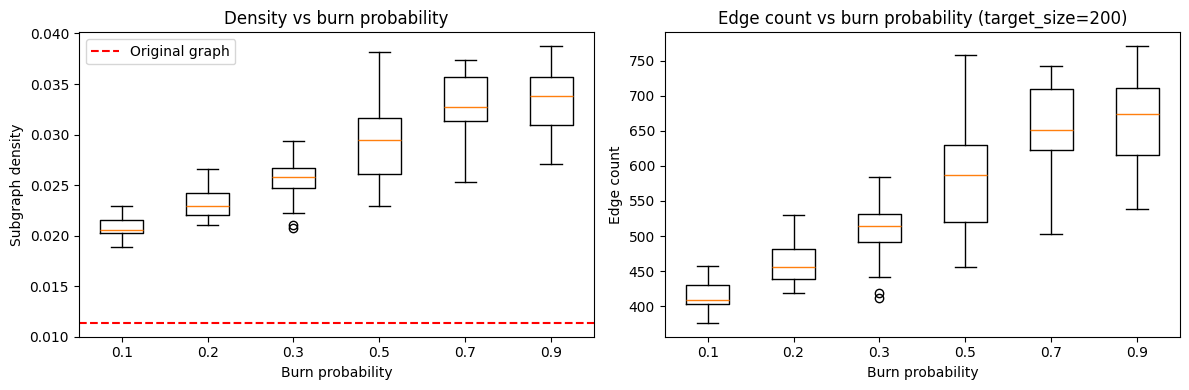

In [3]:
# Show how burn_prob affects subgraph density
burn_probs = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
n_samples = 20
target = 200

results = {}
for p in burn_probs:
    densities = []
    edges_list = []
    for _ in range(n_samples):
        sg = forest_fire_sample(G, target, burn_prob=p)
        densities.append(nx.density(sg))
        edges_list.append(sg.number_of_edges())
    results[p] = {'density': densities, 'edges': edges_list}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.boxplot([results[p]['density'] for p in burn_probs], labels=[str(p) for p in burn_probs])
ax1.axhline(y=nx.density(G), color='r', linestyle='--', label='Original graph')
ax1.set_xlabel('Burn probability')
ax1.set_ylabel('Subgraph density')
ax1.set_title('Density vs burn probability')
ax1.legend()

ax2.boxplot([results[p]['edges'] for p in burn_probs], labels=[str(p) for p in burn_probs])
ax2.set_xlabel('Burn probability')
ax2.set_ylabel('Edge count')
ax2.set_title('Edge count vs burn probability (target_size=200)')

plt.tight_layout()
plt.show()

## 6. Implementation

The forest fire sampling is implemented in `bigg/bigg/extension/preprocessing.py` as `forest_fire_subsample()`. It is a drop-in replacement for `bfs_subsample()`, returning the same tuple format:

```python
(sub_graph_nx, sub_node_data, original_indices)
```

Where:
- `sub_graph_nx`: Induced subgraph with nodes reindexed 0..n-1 in burn order
- `sub_node_data`: Feature/label tensor rows for sampled nodes
- `original_indices`: 1-D tensor mapping new indices to original node IDs

### Sampling with replacement in the pipeline

In `pipeline.py`, the old `partition_graph_bfs` call (which produced non-overlapping partitions) is replaced by a simple loop of independent `forest_fire_subsample` calls:

```python
raw_partitions = []
for _ in range(num_subgraphs):
    raw_partitions.append(forest_fire_subsample(
        graph_nx, node_data,
        target_size=pipeline_args.subsample_size,
        burn_prob=pipeline_args.burn_prob,
    ))
```

Each call samples from the full original graph independently. The `num_subgraphs` parameter (default: `ceil(N / subsample_size)`) controls how many samples to take.

### Restart mechanism

With low burn probability on sparse graphs, the fire can die before reaching `target_size`. When the stack empties, a new random unburned node is selected as a seed and burning continues. This may produce subgraphs with disconnected components, but BiGG handles disconnected graphs (it processes connected components sorted by size during BFS reordering).

### Backward compatibility

The old `bfs_subsample` and `partition_graph_bfs` functions remain in `preprocessing.py` but are no longer used by the pipeline.

## 7. Usage

The `burn_prob` parameter replaces the old `subsample_k` in the CLI:

```bash
# Via SLURM — set BURN_PROB in train_bigg_subsample.slurm
BURN_PROB=0.3

# Via shell script (positional arg 16)
bash scripts/train/train_bigg_subsample.sh reddit -1 1 300 0.001 256 0.3 0.0 0 True zscore 0.1,0.1 true true 2000 0.3

# Or directly via the pipeline
python -m bigg.extension.pipeline \
  -data_dir reddit \
  --subsample \
  -subsample_size 2000 \
  -burn_prob 0.3 \
  ...
```

The save name includes `_pP` (e.g., `_sub6_size2000_p0.3`) instead of the old `_kK` pattern.

### Recommended starting points

| Graph density | Suggested `burn_prob` | Rationale |
|:---|:---:|:---|
| Sparse (avg degree < 10) | 0.5 - 0.7 | Can afford denser samples; more local structure preserved |
| Moderate (avg degree 10-30) | 0.3 - 0.5 | Balance density and BiGG complexity |
| Dense (avg degree > 30) | 0.1 - 0.3 | Keep samples manageable for Fenwick tree |

These are starting points. The optimal value should be determined empirically by comparing downstream benchmark scores across different `burn_prob` settings.

## References

- Leskovec, J. & Faloutsos, C. (2006). *Sampling from Large Graphs.* KDD. (Forest fire sampling)
- Dai, H. et al. (2020). *Scalable Deep Generative Modeling for Sparse Graphs.* ICML. (BiGG architecture and Fenwick tree)